> 📄 **Dokumentacja techniczna:** [docs/01_EDA_analiza.md](../docs/01_EDA_analiza.md) — Data Quality, luki IoT, sync_data.py, kalibracja vs zdjęcia.

# Smart Energy Model - Analiza Eksploracyjna Danych (EDA)

## Cel analizy
1. Analiza danych z instalacji fotowoltaicznej (FoxEss)
2. Porównanie prognoz Tauron z rzeczywistym zużyciem
3. Identyfikacja wzorców zużycia energii
4. Przygotowanie danych do treningu modelu ML

In [47]:
# Import bibliotek
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')


def _find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, here.parent):
        if (cand / 'src').is_dir() and (cand / 'data').is_dir():
            return cand
    return here.parent if here.name == 'notebooks' else here


ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# Konfiguracja wykresów
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Rozmiar wykresów
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Biblioteki zaimportowane pomyślnie")
print(f"ROOT: {ROOT}")

✅ Biblioteki zaimportowane pomyślnie
ROOT: /path/to/smart-energy-model


## 1. Połączenie z bazą danych i wczytanie danych

In [48]:
# Połączenie z bazą danych
db_path = ROOT / 'data' / 'energy_model.db'
conn = sqlite3.connect(db_path)

# Wczytanie danych z FoxEss
query_foxess = """
SELECT 
    timestamp,
    pv_energy_kwh,
    battery_soc_percent,
    battery_power_kw,
    load_energy_kwh,
    grid_import_kwh,
    grid_export_kwh
FROM foxess_data
ORDER BY timestamp
"""

df_foxess = pd.read_sql_query(query_foxess, conn)


def parse_foxess_timestamps(series: pd.Series) -> pd.DatetimeIndex:
    """FoxESS: stare wiersze +02:00, nowsze (od ~14.07) bez strefy — oba to czas lokalny PL."""
    parsed = pd.to_datetime(series, format='mixed', errors='coerce')
    out = []
    for t in parsed:
        if pd.isna(t):
            out.append(pd.NaT)
        else:
            ts = pd.Timestamp(t)
            if ts.tz is not None:
                out.append(ts.tz_convert('Europe/Warsaw').tz_localize(None))
            else:
                out.append(ts)
    return pd.DatetimeIndex(out)


df_foxess['timestamp'] = parse_foxess_timestamps(df_foxess['timestamp'])
df_foxess.set_index('timestamp', inplace=True)
df_foxess.index = pd.DatetimeIndex(df_foxess.index)
df_foxess.sort_index(inplace=True)


def foxess_between(df, start, end):
    """Wytnij okres [start, end] (daty 'YYYY-MM-DD'). Bez .loc['str':] — bezpieczne dla TZ."""
    idx = df.index
    if not isinstance(idx, pd.DatetimeIndex):
        idx = parse_foxess_timestamps(pd.Series(idx))
    elif getattr(idx, 'tz', None) is not None:
        idx = idx.tz_convert('Europe/Warsaw').tz_localize(None)
    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end) + pd.Timedelta(days=1)
    out = df.copy()
    out.index = idx
    return out.loc[(out.index >= t0) & (out.index < t1)]


print(f"📊 Wczytano {len(df_foxess)} rekordów z FoxEss")
print(f"📅 Okres danych: {df_foxess.index.min()} do {df_foxess.index.max()}")
df_foxess.head()

📊 Wczytano 145480 rekordów z FoxEss
📅 Okres danych: 2025-04-25 18:14:07 do 2026-08-11 15:59:32


,pv_energy_kwh,battery_soc_percent,battery_power_kw,load_energy_kwh,grid_import_kwh,grid_export_kwh
timestamp,,,,,,
2025-04-25 18:14:07,-0.003750,96.0,-0.059,-0.000750,0.003000,0.0
2025-04-25 18:18:37,-0.003333,96.0,-0.047,-0.001000,0.002333,0.0
2025-04-25 18:23:07,-0.003333,96.0,-0.012,-0.001417,0.001917,0.0
2025-04-25 18:27:37,-0.003417,96.0,-0.007,-0.001333,0.002083,0.0
2025-04-25 18:32:07,-0.003500,96.0,-0.044,-0.001750,0.001750,0.0


## 1b. Audyt pokrycia danych (luki w FoxESS + dane Tauron)

Kolumna **faza_obecnosci** pochodzi z `src/data/household_context.py` — opisuje profil zużycia (dom pusty, tylko gotowanie, pełne użytkowanie, kemping itd.). Przy porównaniach miesięcznych **nie traktuj outlierów jak normalnego profilu**.


In [49]:
# Audyt: które miesiące mają dane FoxESS (foxess_data)
from src.data.household_context import month_occupancy_label

coverage = pd.read_sql_query("""
    SELECT strftime('%Y-%m', timestamp) AS month,
           COUNT(DISTINCT date(timestamp)) AS days,
           ROUND(SUM(grid_import_kwh), 1) AS import_kwh,
           ROUND(SUM(pv_energy_kwh), 1) AS pv_kwh
    FROM foxess_data
    GROUP BY 1 ORDER BY 1
""", conn)
coverage['faza_obecnosci'] = coverage['month'].apply(
    lambda ym: month_occupancy_label(*map(int, ym.split('-')))
)
print("📅 Pokrycie FoxESS (dni w miesiącu) + faza obecności:")
display(coverage)

missing = coverage[coverage['days'] < 25]['month'].tolist()
if missing:
    print(f"\n⚠️ Luki / niepełne miesiące FoxESS: {', '.join(missing)}")
    print("   (np. 2025-11 … 2026-02 — zima; uzupełnij: python src/data/foxess_fetch_all.py --from … --delay 2)")

# Dane Tauron w bazie
for table, label in [
    ('tauron_forecast', 'Prognozy (blankiety)'),
    ('tauron_bills', 'Rozliczenia / korekty'),
    ('tauron_tariff', 'Cennik'),
]:
    try:
        n = pd.read_sql_query(f'SELECT COUNT(*) AS n FROM {table}', conn).iloc[0]['n']
        print(f"\n📄 {label}: {n} rekordów")
        if n:
            display(pd.read_sql_query(f'SELECT * FROM {table} ORDER BY 1 DESC LIMIT 8', conn))
    except Exception as e:
        print(f"   {table}: {e}")


📅 Pokrycie FoxESS (dni w miesiącu) + faza obecności:


,month,days,import_kwh,pv_kwh,faza_obecnosci
0,2025-04,6,1.7,-0.5,prognoza operatora + błąd falownika
1,2025-05,16,7.5,64.2,błąd falownika + dom pusty
2,2025-06,30,9.8,754.6,dom pusty
3,2025-07,31,13.7,779.5,dom pusty
4,2025-08,31,32.4,871.3,tylko gotowanie
5,2025-09,30,89.6,534.4,pełne użytkowanie + kemping (dom pusty)
6,2025-10,31,208.1,320.1,pełne użytkowanie
7,2025-11,30,634.5,208.8,pełne użytkowanie
8,2025-12,31,941.9,79.2,pełne użytkowanie
9,2026-01,31,1319.2,27.5,pełne użytkowanie



⚠️ Luki / niepełne miesiące FoxESS: 2025-04, 2025-05, 2026-08
   (np. 2025-11 … 2026-02 — zima; uzupełnij: python src/data/foxess_fetch_all.py --from … --delay 2)

📄 Prognozy (blankiety): 6 rekordów


,id,forecast_date,forecast_period,forecast_zone1_kwh,forecast_zone2_kwh,forecast_total_kwh,forecast_energy_cost,forecast_distribution_cost,forecast_fixed_costs,forecast_total_cost,source,notes
0,6,2026-01-01,2026-01_2026-02,None,None,984.0,916.52,None,None,1127.34,blankiet_prognoza_T/K1/0411004/25/6,Blankiet T/K1/0411004/25/6 | 01/01/2026–28/02/...
1,5,2025-11-01,2025-11_2025-12,None,None,1016.0,936.13,None,None,1151.43,blankiet_prognoza_T/K1/0411004/25/5,Blankiet T/K1/0411004/25/5 | 01/11/2025–31/12/...
2,4,2025-09-01,2025-09_2025-10,None,None,1016.0,872.48,None,None,1073.15,blankiet_prognoza_T/K1/0411004/25/4,Blankiet T/K1/0411004/25/4 | 01/09/2025–31/10/...
3,3,2025-07-01,2025-07_2025-08,None,None,1034.0,820.13,None,None,1008.77,blankiet_prognoza_T/K1/0411004/25/3,Blankiet T/K1/0411004/25/3 | 01/07/2025–31/08/...
4,2,2025-05-01,2025-05_2025-06,None,None,1016.0,801.22,None,None,985.51,blankiet_prognoza_T/K1/0411004/25/2,Blankiet T/K1/0411004/25/2 | 01/05/2025–30/06/...
5,1,2025-03-28,2025-03_2025-04,None,None,566.0,462.36,None,None,568.69,blankiet_prognoza_T/K1/0411004/25/1,Blankiet T/K1/0411004/25/1 | 28/03/2025–30/04/...



📄 Rozliczenia / korekty: 17 rekordów


,id,bill_date,billing_period_start,billing_period_end,actual_zone1_kwh,actual_zone2_kwh,actual_total_kwh,actual_energy_cost,actual_distribution_cost,actual_fixed_costs,actual_total_cost,energy_exported_kwh,energy_exported_value,bill_number,pdf_path
0,24,2026-08-10,2026-07-01,2026-07-31,6.0,16.0,22.0,36.02,43.23,0.49,97.48,407.0,NaN,rozliczenie_2026-07-01_2026-07-31,typ=rozliczenie|okres=2026-07-01_2026-07-31|te...
1,23,2026-06-30,2026-06-01,2026-06-30,10.0,26.0,36.0,42.67,45.66,0.45,108.67,514.0,NaN,rozliczenie_06.2026_2026-06-01_30,Rozliczenie 06.2026|data_wystawienia=2026-07-0...
2,22,2025-07-31,2025-07-01,2025-07-31,3.0,9.0,12.0,23.55,19.70,0.00,53.21,678.0,NaN,rozliczenie_07.2025_2025-07-01_31,Rozliczenie 07.2025|G12W|14kW|cennik=EE_GD_MIX...
3,21,2026-07-15,2026-05-01,2026-05-31,7.0,31.0,38.0,42.89,45.02,0.53,108.13,403.0,71.46,T/K1/BC389/0009/26,Korekta 05.2026|do_faktury=T/K1/BC389/0006/26 ...
4,17,2026-04-30,2026-04-01,2026-04-30,41.0,93.0,134.0,89.93,63.58,1.07,188.82,288.0,NaN,rozliczenie_04.2026_2026-04-01_30,Rozliczenie 04.2026|G12W|14kW|cennik=EE_GD_MIX...
5,16,2026-02-28,2026-02-01,2026-02-28,59.0,684.0,743.0,347.20,126.27,4.02,582.36,71.0,NaN,rozliczenie_02.2026_2026-02-01_28,Rozliczenie 02.2026|G12W|14kW|cennik=EE_GD_MIX...
6,15,2026-03-31,2026-03-01,2026-03-31,57.0,166.0,223.0,130.31,76.47,1.47,254.36,246.0,NaN,rozliczenie_03.2026_2026-03-01_31,Rozliczenie 03.2026|G12W|14kW|cennik=EE_GD_MIX...
7,14,2026-06-22,2026-01-01,2026-01-31,178.0,997.0,1175.0,551.80,200.21,6.20,924.96,8.0,NaN,T/K1/BC389/0007/26,Korekta 01.2026|do_faktury=T/K1/BC389/0002/26 ...



📄 Cennik: 15 rekordów


,id,valid_from,valid_to,tariff_name,price_zone1_day,price_zone2_night,distribution_zone1,distribution_zone2,subscription_fee_monthly,power_fee_monthly,transition_fee_monthly,oze_fee_kwh,cogenerative_fee_kwh,notes
0,23,2025-07-01,None,G12w,0.5050,0.5050,0.3592,0.0839,22.040,2.86,None,0.0035,0.003,Rozliczenie 07.2025 | 01/07/2025 - 31/07/2025....
1,22,2026-05-01,None,G12w,0.6244,0.4163,0.3630,0.0844,30.170,34.91,None,0.0073,0.003,Rozliczenie 05.2026 | faktura /0006/26 | wysta...
2,18,2026-04-01,None,G12w,0.6244,0.4163,0.3630,0.0844,30.170,24.05,None,0.0073,NaN,Rozliczenie 04.2026 | 01/04/2026 - 30/04/2026....
3,17,2026-02-01,None,G12w,0.6244,0.4163,0.3630,0.0844,30.170,24.05,None,0.0073,NaN,Rozliczenie 02.2026 | 01/02/2026 - 28/02/2026....
4,16,2026-03-01,None,G12w,0.6244,0.4163,0.3630,0.0844,30.170,24.05,None,0.0073,NaN,Rozliczenie 03.2026 | 01/03/2026 - 31/03/2026....
5,15,2026-01-01,None,G12w,0.6244,0.4163,0.3629,0.0843,30.170,24.05,None,0.0073,NaN,Rozliczenie 01.2026 | 01/01/2026 - 31/01/2026....
6,14,2025-12-01,None,G12w,0.5050,0.5050,0.3592,0.0839,24.601,NaN,None,0.0035,NaN,Rozliczenie 12.2025 | 01/12/2025 - 31/12/2025....
7,13,2025-11-01,None,G12w,0.5050,0.5050,0.3592,0.0839,24.601,NaN,None,0.0035,NaN,Rozliczenie 11.2025 | 01/11/2025 - 30/11/2025....


## 1c. Zima 2025/2026 — import z sieci (luka danych FoxESS)

Okres **2025-11 → 2026-03**: niska produkcja PV, duży import z sieci.  
Po uzupełnieniu API (`foxess_fetch_all.py --from 2025-11-01 …`) wykresy poniżej się wypełnią.


🌨️ Okres zimowy: 2025-11-01 → 2026-03-31 (151 dni kalendarzowych)
   Rekordów FoxESS (5 min): 48,231
   Dni z danymi w bazie: 151 / 151


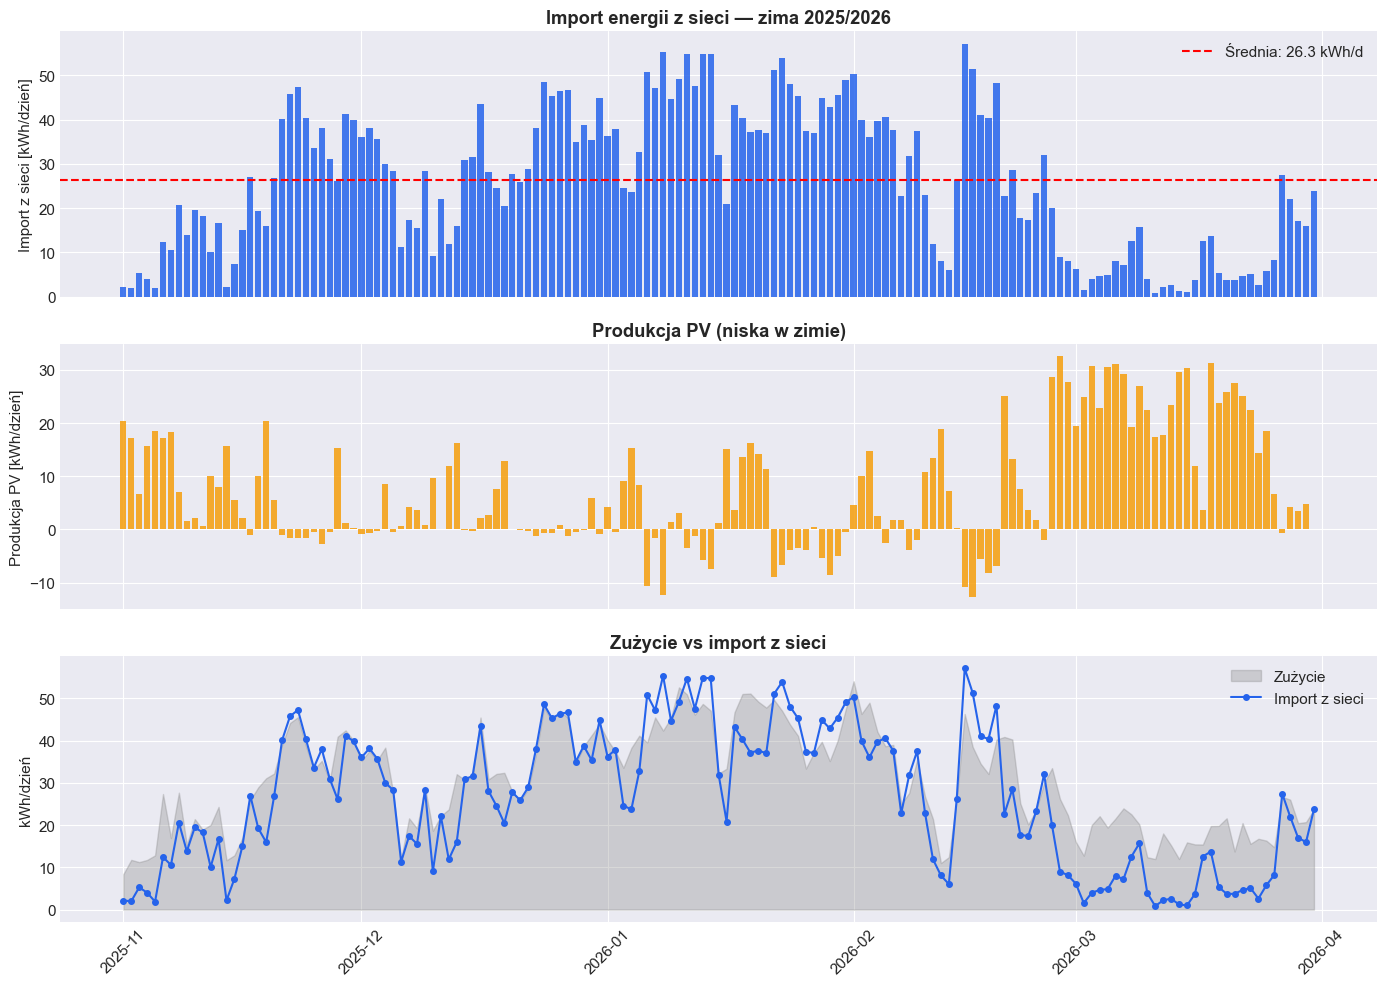


📊 Zima — sumy (tylko dni z danymi w bazie):
   Import z sieci:  3972.2 kWh
   Produkcja PV:    1086.9 kWh
   Zużycie (loads): 4610.4 kWh
   Stosunek import/PV: 3.7×

📊 Średnie dzienne — zima vs lato:


,Import z sieci [kWh/d],PV [kWh/d]
Zima 2025/26,26.305652,7.198209
Lato 2025 (VI–VIII),0.606394,26.145983


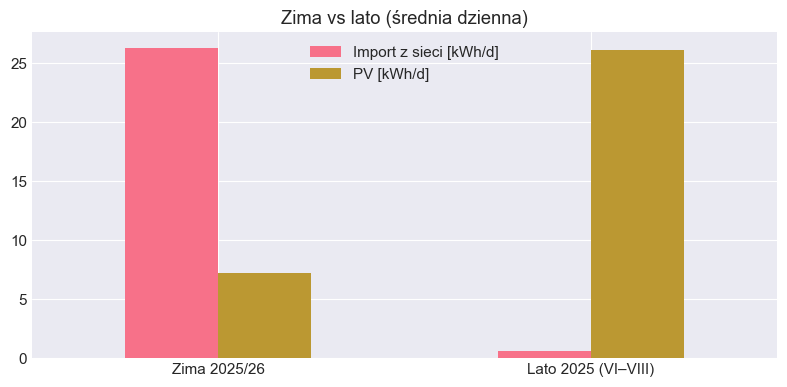

In [50]:
WINTER_START = '2025-11-01'
WINTER_END = '2026-03-31'

# Indeks z timezone (+02:00) — .loc['2025-11-01':] pada; filtrujemy po Timestamp
_idx = pd.to_datetime(df_foxess.index)
if hasattr(_idx, 'tz') and _idx.tz is not None:
    _idx = _idx.tz_localize(None)
_w_start = pd.Timestamp(WINTER_START)
_w_end = pd.Timestamp(WINTER_END) + pd.Timedelta(days=1)

df_w = df_foxess.copy()
df_w.index = _idx
df_w = df_w[(df_w.index >= _w_start) & (df_w.index < _w_end)].copy()
daily_w = df_w.resample('D').agg({
    'pv_energy_kwh': 'sum',
    'load_energy_kwh': 'sum',
    'grid_import_kwh': 'sum',
    'grid_export_kwh': 'sum',
    'battery_soc_percent': 'mean',
})
full_idx = pd.date_range(WINTER_START, WINTER_END, freq='D')
daily_w = daily_w.reindex(full_idx)
daily_w.index.name = 'date'

n_days_range = (pd.Timestamp(WINTER_END) - pd.Timestamp(WINTER_START)).days + 1
days_in_db = daily_w['grid_import_kwh'].notna().sum() if len(daily_w) else 0

print(f'🌨️ Okres zimowy: {WINTER_START} → {WINTER_END} ({n_days_range} dni kalendarzowych)')
print(f'   Rekordów FoxESS (5 min): {len(df_w):,}')
print(f'   Dni z danymi w bazie: {days_in_db} / {n_days_range}')

if len(df_w) == 0:
    print('\n⚠️ Brak punktów FoxESS w zimie — uruchom import, np.:')
    print('   python src/data/foxess_fetch_all.py --from 2025-11-01 --to 2025-11-30 --delay 2')
else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    imp = daily_w['grid_import_kwh'].fillna(0)
    imp_plot = imp.where(daily_w['grid_import_kwh'].notna(), np.nan)
    axes[0].bar(daily_w.index, imp_plot, color='#2563eb', alpha=0.85, width=0.8)
    axes[0].set_ylabel('Import z sieci [kWh/dzień]')
    axes[0].set_title('Import energii z sieci — zima 2025/2026', fontweight='bold')
    axes[0].axhline(daily_w['grid_import_kwh'].mean(), color='red', ls='--',
                    label=f"Średnia: {daily_w['grid_import_kwh'].mean():.1f} kWh/d")
    axes[0].legend()

    axes[1].bar(daily_w.index, daily_w['pv_energy_kwh'], color='#f59e0b', alpha=0.85, width=0.8)
    axes[1].set_ylabel('Produkcja PV [kWh/dzień]')
    axes[1].set_title('Produkcja PV (niska w zimie)', fontweight='bold')

    ax2 = axes[2]
    ax2.fill_between(daily_w.index, daily_w['load_energy_kwh'], alpha=0.3, color='gray', label='Zużycie')
    ax2.plot(daily_w.index, daily_w['grid_import_kwh'], 'o-', color='#2563eb', label='Import z sieci', ms=4)
    ax2.set_ylabel('kWh/dzień')
    ax2.set_title('Zużycie vs import z sieci', fontweight='bold')
    ax2.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    if days_in_db < n_days_range * 0.5:
        axes[0].text(0.5, 0.95, 'LUKA DANYCH — uzupełnij foxess_fetch_all.py',
                     transform=axes[0].transAxes, ha='center', va='top',
                     fontsize=12, color='darkred', fontweight='bold')

    print(f"\n📊 Zima — sumy (tylko dni z danymi w bazie):")
    print(f"   Import z sieci:  {daily_w['grid_import_kwh'].sum(skipna=True):.1f} kWh")
    print(f"   Produkcja PV:    {daily_w['pv_energy_kwh'].sum():.1f} kWh")
    print(f"   Zużycie (loads): {daily_w['load_energy_kwh'].sum():.1f} kWh")
    if daily_w['pv_energy_kwh'].sum() > 0:
        print(f"   Stosunek import/PV: {daily_w['grid_import_kwh'].sum()/daily_w['pv_energy_kwh'].sum():.1f}×")

# Porównanie: zima vs lato (czerwiec 2025 jeśli jest w bazie)
SUMMER_START, SUMMER_END = '2025-06-01', '2025-08-31'
df_s = foxess_between(df_foxess, SUMMER_START, SUMMER_END)
if len(df_s) > 0 and len(df_w) > 0:
    comp = pd.DataFrame({
        'Import z sieci [kWh/d]': [
            df_w['grid_import_kwh'].resample('D').sum().mean(),
            df_s['grid_import_kwh'].resample('D').sum().mean(),
        ],
        'PV [kWh/d]': [
            df_w['pv_energy_kwh'].resample('D').sum().mean(),
            df_s['pv_energy_kwh'].resample('D').sum().mean(),
        ],
    }, index=['Zima 2025/26', 'Lato 2025 (VI–VIII)'])
    print('\n📊 Średnie dzienne — zima vs lato:')
    display(comp)
    comp.plot(kind='bar', figsize=(8, 4), rot=0, title='Zima vs lato (średnia dzienna)')
    plt.tight_layout()
    plt.show()
elif len(df_w) == 0:
    pass
else:
    print('\n(i) Brak danych letnich VI–VIII 2025 do porównania w bazie')


In [51]:
# Podstawowe statystyki
print("\n📈 Podstawowe statystyki danych FoxEss:\n")
df_foxess.describe()


📈 Podstawowe statystyki danych FoxEss:



,pv_energy_kwh,battery_soc_percent,battery_power_kw,load_energy_kwh,grid_import_kwh,grid_export_kwh
count,145480.000000,145480.000000,145480.000000,145480.000000,145480.000000,145480.000000
mean,0.053407,66.280795,-0.005905,0.049206,0.031756,0.035241
std,0.145601,35.158864,1.393202,0.080624,0.118621,0.090505
min,-0.945333,0.000000,-10.326000,-0.721583,0.000000,0.000000
25%,0.000000,33.000000,-0.195000,0.004583,0.000000,0.000000
50%,0.007417,81.000000,-0.008000,0.013000,0.002583,0.000000
75%,0.078833,98.000000,0.000000,0.036667,0.008417,0.000000
max,0.832250,100.000000,10.835000,1.173167,1.421333,0.609500


## 2. Analiza produkcji fotowoltaiki

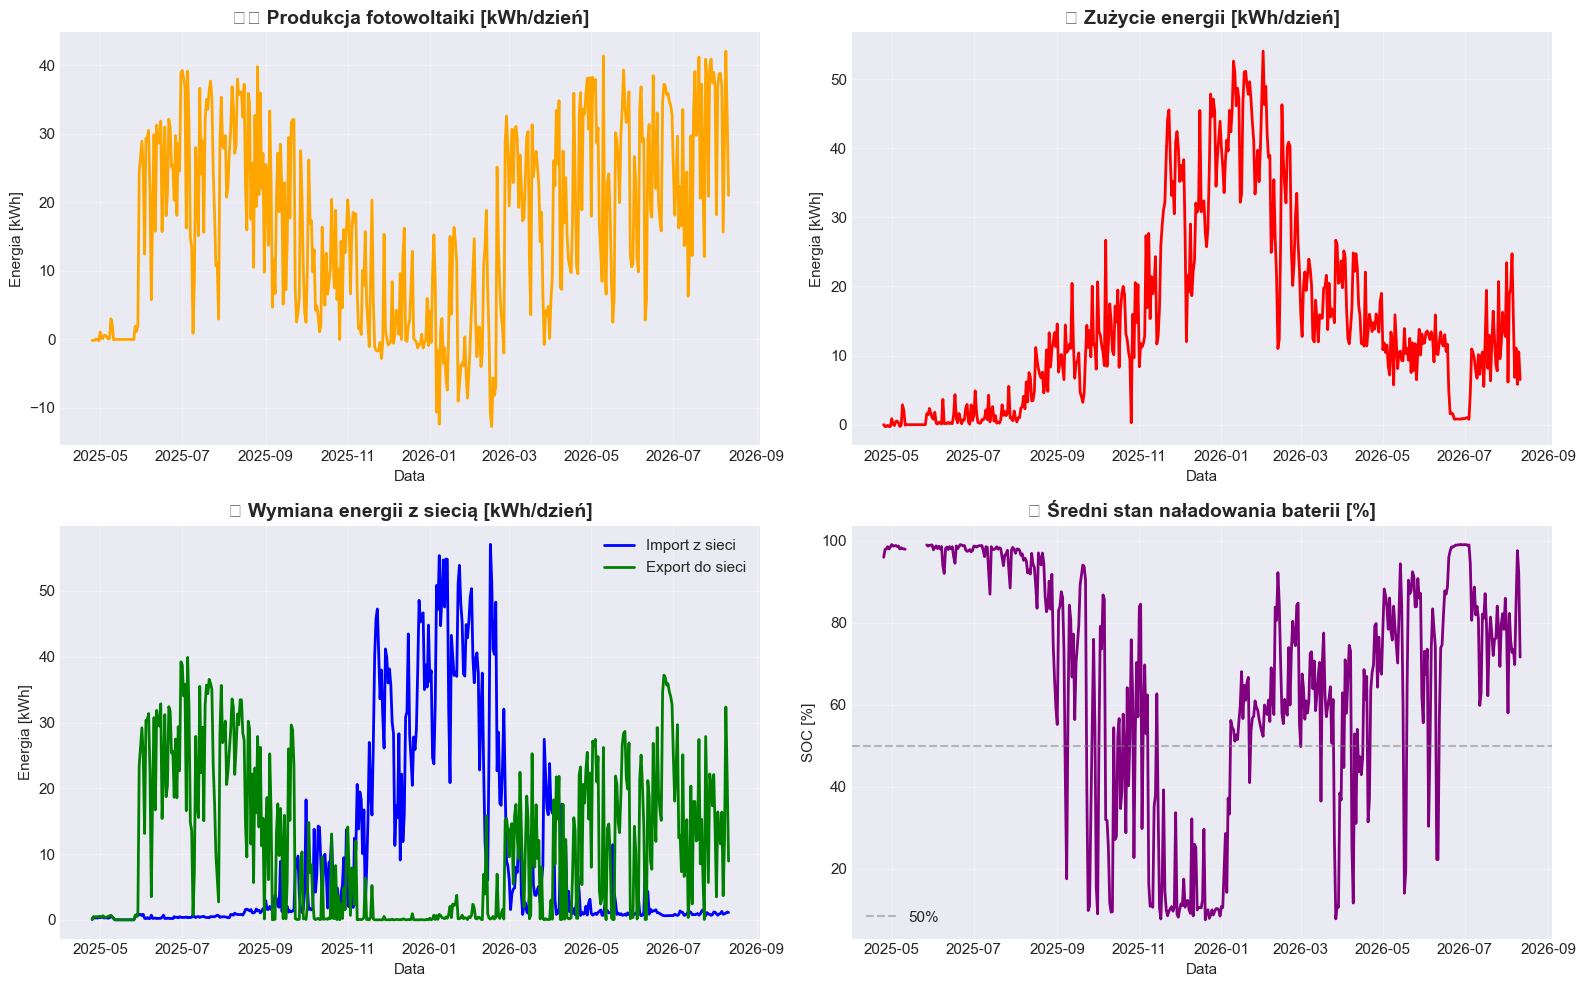


📊 Podsumowanie dzienne:
Średnia produkcja PV: 16.39 kWh/dzień
Średnie zużycie: 15.10 kWh/dzień
Średni import: 9.75 kWh/dzień
Średni export: 10.82 kWh/dzień


In [52]:
# Dzienna produkcja PV
df_daily = df_foxess.resample('D').agg({
    'pv_energy_kwh': 'sum',
    'load_energy_kwh': 'sum',
    'grid_import_kwh': 'sum',
    'grid_export_kwh': 'sum',
    'battery_soc_percent': 'mean'
})

# Wykres produkcji PV
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Produkcja PV w czasie
axes[0, 0].plot(df_daily.index, df_daily['pv_energy_kwh'], color='orange', linewidth=2)
axes[0, 0].set_title('☀️ Produkcja fotowoltaiki [kWh/dzień]', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Energia [kWh]')
axes[0, 0].grid(True, alpha=0.3)

# 2. Zużycie energii
axes[0, 1].plot(df_daily.index, df_daily['load_energy_kwh'], color='red', linewidth=2)
axes[0, 1].set_title('🏠 Zużycie energii [kWh/dzień]', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Data')
axes[0, 1].set_ylabel('Energia [kWh]')
axes[0, 1].grid(True, alpha=0.3)

# 3. Import vs Export
axes[1, 0].plot(df_daily.index, df_daily['grid_import_kwh'], label='Import z sieci', color='blue', linewidth=2)
axes[1, 0].plot(df_daily.index, df_daily['grid_export_kwh'], label='Export do sieci', color='green', linewidth=2)
axes[1, 0].set_title('⚡ Wymiana energii z siecią [kWh/dzień]', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Data')
axes[1, 0].set_ylabel('Energia [kWh]')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Średni SOC baterii
axes[1, 1].plot(df_daily.index, df_daily['battery_soc_percent'], color='purple', linewidth=2)
axes[1, 1].set_title('🔋 Średni stan naładowania baterii [%]', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Data')
axes[1, 1].set_ylabel('SOC [%]')
axes[1, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Podsumowanie
print("\n📊 Podsumowanie dzienne:")
print(f"Średnia produkcja PV: {df_daily['pv_energy_kwh'].mean():.2f} kWh/dzień")
print(f"Średnie zużycie: {df_daily['load_energy_kwh'].mean():.2f} kWh/dzień")
print(f"Średni import: {df_daily['grid_import_kwh'].mean():.2f} kWh/dzień")
print(f"Średni export: {df_daily['grid_export_kwh'].mean():.2f} kWh/dzień")

## 2b. Walidacja pogody (Open-Meteo) vs produkcja PV

Dane pogodowe: tabela `weather_data` (skrypt `scripts/fetch_weather.py`).  
Okres: od **01.06.2025** (pierwszy pełny miesiąc po naprawie falownika 30.05) — ten sam start co okno ML / RF.

**Cel:** sprawdzić, czy **suma dzienna radiacji** i **zachmurzenie** tłumaczą produkcję PV — sygnał pod **Random Forest** (16 cech) i decyzje o ładowaniu baterii w nocy.

**Metryka PV:** `pv_kwh_solar` (FoxESS, tylko dodatnia produkcja bez artefaktu rozładowania baterii).

📅 Okres: 2025-06-01 → 2026-08-11 | dni wspólne: 437
Korelacja PV (słońce) ↔ suma radiacji (Open-Meteo):  0.873
Korelacja PV (słońce) ↔ (−zachmurzenie):               0.677
✅ Korelacja radiacji > 0,7 = dobry sygnał pod RF (Random Forest) i sterowanie baterią.


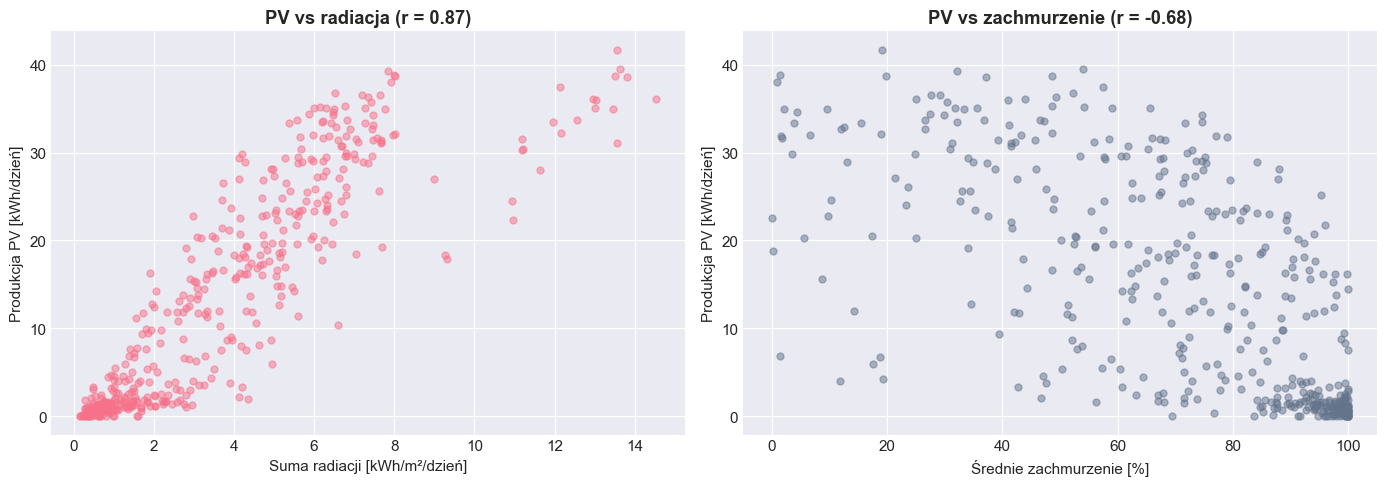

In [53]:
# Korelacja PV ↔ pogoda (dzienne sumy)
from src.data.household_context import FOXESS_RELIABLE_START
from src.data.weather_api import load_daily_pv, load_daily_weather

DB_PATH = str(ROOT / 'data' / 'energy_model.db')
WX_START = FOXESS_RELIABLE_START.isoformat()  # 2025-06-01 — okno ML / RF
WX_END = df_daily.index.max().strftime('%Y-%m-%d')

weather = load_daily_weather(DB_PATH, WX_START, WX_END)
pv_daily = load_daily_pv(DB_PATH, WX_START, WX_END)
merged_wx = weather.merge(pv_daily, on='day', how='inner')
PV_COL = 'pv_kwh_solar'

if merged_wx.empty:
    print('⚠️ Brak danych pogodowych — uruchom: python scripts/fetch_weather.py')
else:
    corr_rad = merged_wx[PV_COL].corr(merged_wx['radiation_kwh_m2'])
    corr_cloud = merged_wx[PV_COL].corr(-merged_wx['cloud_cover_avg'])
    corr_cloud_raw = merged_wx[PV_COL].corr(merged_wx['cloud_cover_avg'])

    print(f'📅 Okres: {WX_START} → {WX_END} | dni wspólne: {len(merged_wx)}')
    print(f'Korelacja PV (słońce) ↔ suma radiacji (Open-Meteo):  {corr_rad:.3f}')
    print(f'Korelacja PV (słońce) ↔ (−zachmurzenie):               {corr_cloud:.3f}')
    rf_hint = '✅' if corr_rad >= 0.7 else '⚠️'
    print(f'{rf_hint} Korelacja radiacji > 0,7 = dobry sygnał pod RF (Random Forest) i sterowanie baterią.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(merged_wx['radiation_kwh_m2'], merged_wx[PV_COL], alpha=0.5, s=25)
    axes[0].set_xlabel('Suma radiacji [kWh/m²/dzień]')
    axes[0].set_ylabel('Produkcja PV [kWh/dzień]')
    axes[0].set_title(f'PV vs radiacja (r = {corr_rad:.2f})', fontweight='bold')

    axes[1].scatter(merged_wx['cloud_cover_avg'], merged_wx[PV_COL], alpha=0.5, s=25, color='#64748b')
    axes[1].set_xlabel('Średnie zachmurzenie [%]')
    axes[1].set_ylabel('Produkcja PV [kWh/dzień]')
    axes[1].set_title(f'PV vs zachmurzenie (r = {corr_cloud_raw:.2f})', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. Analiza autokonsumpcji (Self-consumption)

💡 Ujemna autokonsumpcja w V 2025 = export > PV w danych FoxESS (błędny tryb falownika).
   Wykres: cała dostępna historia od 2025-04-25 (474 dni).
💡 Wykres Tauron (§4) = POBÓR z sieci (faktura), nie autokonsumpcja PV.


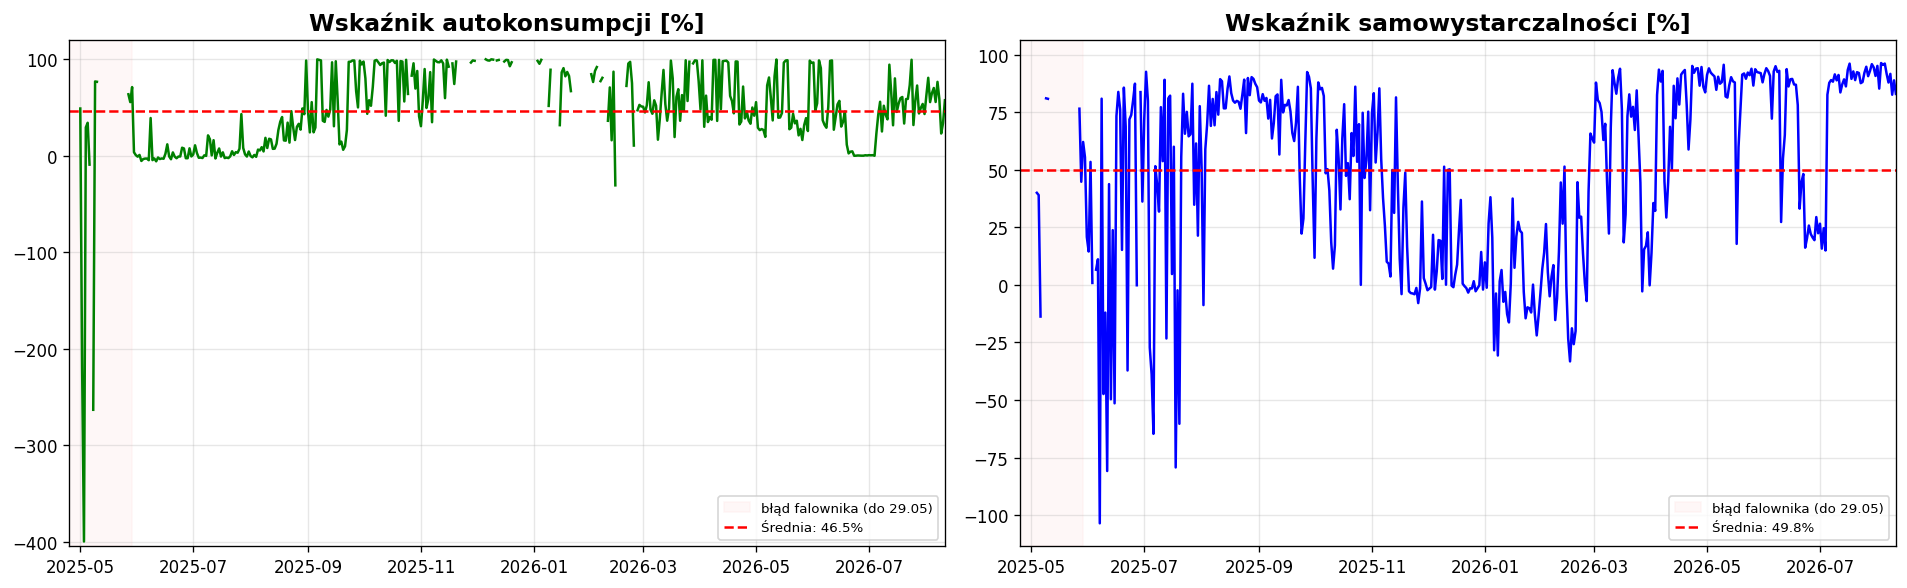


🎯 Średnia autokonsumpcja (cała historia): 46.5%
🎯 Średnia samowystarczalność (cała historia): 49.8%


In [15]:
# Wskaźniki autokonsumpcji i samowystarczalności (FoxESS, dzienne sumy)
# Autokonsumpcja [%] = (PV − export do sieci) / PV — gdy export > PV → ujemne % (artefakt danych).
# Maj 2025: błędne ustawienia falownika → małe PV, export z baterii → szpilki −1000% (NIE interpretować).

from src.data.household_context import FOXESS_DATA_START, PV_INVERTER_MISCONFIG_END

df_daily['self_consumption_kwh'] = df_daily['pv_energy_kwh'] - df_daily['grid_export_kwh']
pv_pos = df_daily['pv_energy_kwh'] > 0.1
df_daily['self_consumption_rate'] = np.where(
    pv_pos,
    (df_daily['self_consumption_kwh'] / df_daily['pv_energy_kwh'] * 100),
    np.nan,
)
load_pos = df_daily['load_energy_kwh'] > 0.1
df_daily['self_sufficiency_rate'] = np.where(
    load_pos,
    (df_daily['load_energy_kwh'] - df_daily['grid_import_kwh']) / df_daily['load_energy_kwh'] * 100,
    np.nan,
)

# Pełna historia FoxESS (od pierwszych danych w chmurze) — w tym maj 2025 z artefaktem falownika
df_plot = df_daily.copy()

print('💡 Ujemna autokonsumpcja w V 2025 = export > PV w danych FoxESS (błędny tryb falownika).')
print(f'   Wykres: cała dostępna historia od {FOXESS_DATA_START} ({len(df_plot)} dni).')
print('💡 Wykres Tauron (§4) = POBÓR z sieci (faktura), nie autokonsumpcja PV.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
xmin, xmax = df_plot.index.min(), df_plot.index.max()
mis_end = pd.Timestamp(PV_INVERTER_MISCONFIG_END.isoformat())

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.axvspan(xmin, mis_end, color='#fee2e2', alpha=0.25, label='błąd falownika (do 29.05)')

axes[0].plot(df_plot.index, df_plot['self_consumption_rate'], color='green', linewidth=1.5)
axes[0].set_title('📈 Wskaźnik autokonsumpcji [%]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Autokonsumpcja [%]')
axes[0].axhline(y=df_plot['self_consumption_rate'].mean(), color='red', linestyle='--',
                label=f'Średnia: {df_plot["self_consumption_rate"].mean():.1f}%')
# Bez sztucznego ylim — widać majowe skoki (export > PV); opcjonalnie przycięcie tylko do prezentacji:
axes[0].set_ylim(min(-120, df_plot['self_consumption_rate'].min(skipna=True) - 5), 120)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_plot.index, df_plot['self_sufficiency_rate'], color='blue', linewidth=1.5)
axes[1].set_title('📈 Wskaźnik samowystarczalności [%]', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Samowystarczalność [%]')
axes[1].axhline(y=df_plot['self_sufficiency_rate'].mean(), color='red', linestyle='--',
                label=f'Średnia: {df_plot["self_sufficiency_rate"].mean():.1f}%')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Średnia autokonsumpcja (cała historia): {df_plot['self_consumption_rate'].mean():.1f}%")
print(f"🎯 Średnia samowystarczalność (cała historia): {df_plot['self_sufficiency_rate'].mean():.1f}%")

## 4. Porównanie: Prognoza Tauron vs Rzeczywistość

📊 Prognozy: 6 blankietów | Faktury: 14 miesięcy

📋 Prognoza vs suma faktur (ten sam okres 2-miesięczny):
forecast_date             okres prognoza_kwh faktura_kwh delta_kwh
   2025-03-28 2025-03 – 2025-04          566           1      -565
   2025-05-01 2025-05 – 2025-06         1016          42      -974
   2025-07-01 2025-07 – 2025-08         1034          39      -995
   2025-09-01 2025-09 – 2025-10         1016         263      -753
   2025-11-01 2025-11 – 2025-12         1016        1415      +399
   2026-01-01 2026-01 – 2026-02          984         743      -241

📌 Wybrane miesiące (czerwone słupki, lewy wykres):
   2025-11: 567 kWh
   2026-03: 223 kWh

💡 Prawy wykres: blankiety od 2025-06-01 (bez remontu V–V 2025)


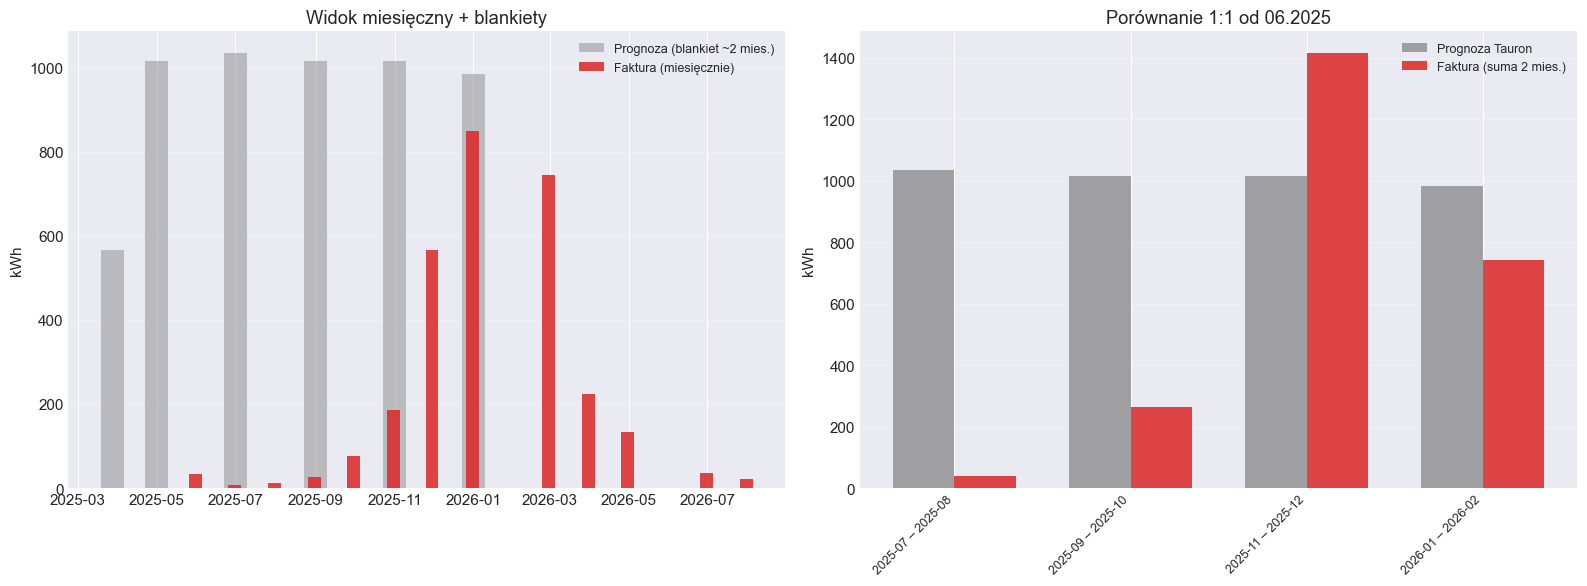

In [55]:
# Prognoza Tauron (blankiety ~2 mies.) vs rzeczywisty POBÓR z faktur
# Nie używaj df_daily['load_energy_kwh'] — to dzienne zużycie FoxESS (błąd skali vs prognoza).

query_forecast = """
SELECT forecast_date, forecast_period, forecast_total_kwh
FROM tauron_forecast ORDER BY forecast_date
"""
query_bills = """
SELECT billing_period_end AS okres_koniec, billing_period_start,
       actual_total_kwh AS pobor_kwh
FROM tauron_bills
WHERE bill_number LIKE 'rozliczenie%'
ORDER BY billing_period_start
"""

import calendar
from src.data.household_context import FOXESS_RELIABLE_START

def _period_bounds(forecast_period: str):
    """'2025-11_2025-12' → ('2025-11-01', '2025-12-31')"""
    a, b = forecast_period.split('_')
    y1, m1 = map(int, a.split('-'))
    y2, m2 = map(int, b.split('-'))
    last_day = calendar.monthrange(y2, m2)[1]
    return f'{y1}-{m1:02d}-01', f'{y2}-{m2:02d}-{last_day:02d}'

try:
    df_fc = pd.read_sql_query(query_forecast, conn)
    df_bills = pd.read_sql_query(query_bills, conn)
    df_fc['forecast_date'] = pd.to_datetime(df_fc['forecast_date'])
    df_bills['okres_koniec'] = pd.to_datetime(df_bills['okres_koniec'])
    df_bills['billing_period_start'] = pd.to_datetime(df_bills['billing_period_start'])

    if len(df_fc) == 0 or len(df_bills) == 0:
        print('⚠️ Brak prognoz lub faktur w bazie')
    else:
        print(f'📊 Prognozy: {len(df_fc)} blankietów | Faktury: {len(df_bills)} miesięcy')

        # Porównanie jabłka z jabłkami: suma faktur za 2 miesiące blankietu
        pairs = []
        for _, fc in df_fc.iterrows():
            p_start, p_end = _period_bounds(fc['forecast_period'])
            mask = (df_bills['billing_period_start'] >= p_start) & (
                df_bills['billing_period_start'] <= p_end)
            actual_sum = df_bills.loc[mask, 'pobor_kwh'].sum()
            pairs.append({
                'forecast_date': fc['forecast_date'],
                'okres': fc['forecast_period'].replace('_', ' – '),
                'prognoza_kwh': fc['forecast_total_kwh'],
                'faktura_kwh': actual_sum,
                'delta_kwh': actual_sum - fc['forecast_total_kwh'],
            })
        df_pair = pd.DataFrame(pairs)
        print('\n📋 Prognoza vs suma faktur (ten sam okres 2-miesięczny):')
        print(df_pair.to_string(index=False, formatters={
            'prognoza_kwh': '{:.0f}'.format,
            'faktura_kwh': '{:.0f}'.format,
            'delta_kwh': '{:+.0f}'.format,
        }))

        print('\n📌 Wybrane miesiące (czerwone słupki, lewy wykres):')
        for m in ['2025-11-01', '2026-03-01']:
            r = df_bills[df_bills['billing_period_start'] == pd.Timestamp(m)]
            if len(r):
                print(f"   {m[:7]}: {r['pobor_kwh'].iloc[0]:.0f} kWh")

        # Prawy wykres: od 2025-06-01 (jak okno ML / korelacja pogodowa)
        df_pair_roi = df_pair[df_pair['forecast_date'] >= pd.Timestamp(FOXESS_RELIABLE_START.isoformat())].copy()
        print(f'\n💡 Prawy wykres: blankiety od {FOXESS_RELIABLE_START} (bez remontu V–V 2025)')

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        ax = axes[0]
        ax.bar(df_fc['forecast_date'], df_fc['forecast_total_kwh'], width=18,
               alpha=0.45, label='Prognoza (blankiet ~2 mies.)', color='gray')
        ax.bar(df_bills['okres_koniec'], df_bills['pobor_kwh'], width=10,
               alpha=0.85, label='Faktura (miesięcznie)', color='#dc2626')
        ax.set_title('Widok miesięczny + blankiety')
        ax.set_ylabel('kWh')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

        ax = axes[1]
        x = np.arange(len(df_pair_roi))
        w = 0.35
        ax.bar(x - w/2, df_pair_roi['prognoza_kwh'], w, label='Prognoza Tauron', color='gray', alpha=0.7)
        ax.bar(x + w/2, df_pair_roi['faktura_kwh'], w, label='Faktura (suma 2 mies.)', color='#dc2626', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(df_pair_roi['okres'], rotation=45, ha='right', fontsize=9)
        ax.set_title(f'Porównanie 1:1 od {FOXESS_RELIABLE_START.strftime("%m.%Y")}')
        ax.set_ylabel('kWh')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f'⚠️ Błąd: {e}')

## 5. Analiza godzinowa — profile zużycia

**Uwaga (FoxESS):** surowe `pv_energy_kwh` bywa **ujemne w nocy** (ok. 4:00 i 22:00), gdy bateria **ładuje się z sieci** — API raportuje to jako ujemną „generację”, choć paneli nie ma. Na wykresie PV obcinamy wartości do `≥ 0` (`clip`); surowe dane zostają w bazie do analizy baterii.

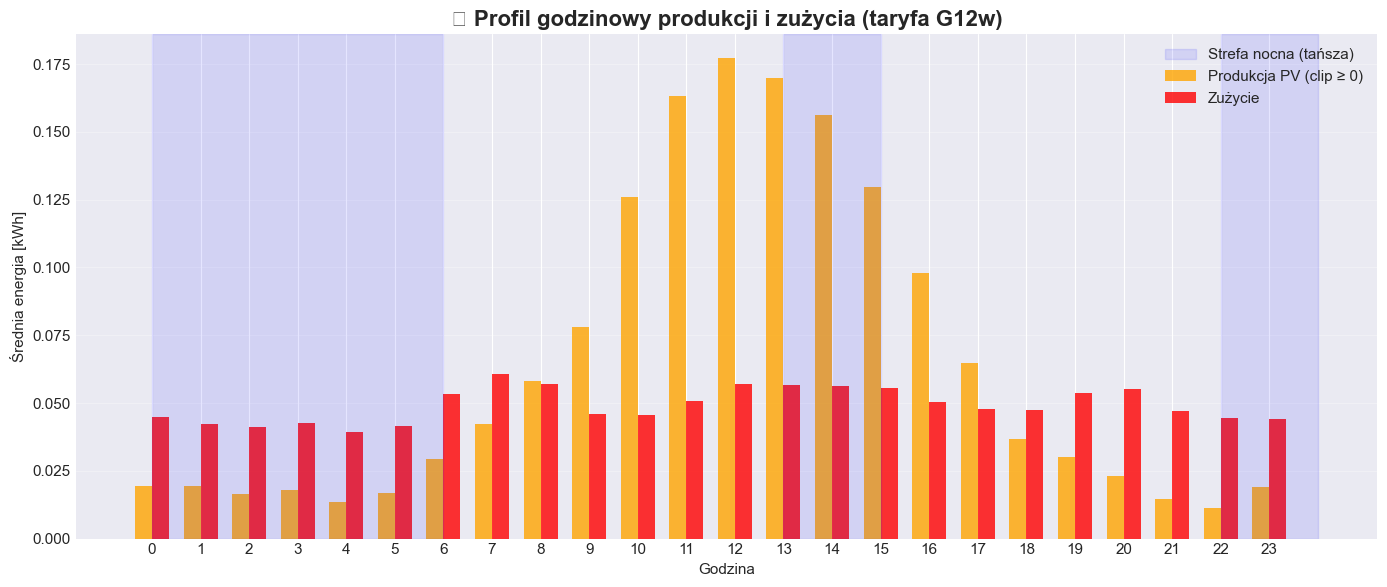


📌 Surowe pv_energy_kwh < 0: 17,174 rekordów (11.8%) — głównie ładowanie baterii w taniej strefie G12w

💡 Analiza profilu godzinowego:
   - Niebieskie obszary = Strefa nocna G12w (tańsza energia)
   - Białe obszary = Strefa dzienna G12w (droższa energia)
   - Ujemne PV w surowych danych (np. 4:00, 22:00) = artefakt FoxESS przy ładowaniu z sieci — na wykresie obcięte
   ➡️  Optymalnie: ładować baterię w strefie nocnej, rozładowywać w dziennej


In [56]:
# Profil godzinowy — upewnij się, że indeks to DatetimeIndex (inaczej brak .hour)
if not isinstance(df_foxess.index, pd.DatetimeIndex):
    df_foxess.index = parse_foxess_timestamps(pd.Series(df_foxess.index))
elif getattr(df_foxess.index, 'tz', None) is not None:
    df_foxess.index = df_foxess.index.tz_convert('Europe/Warsaw').tz_localize(None)
df_foxess['hour'] = df_foxess.index.hour
# PV na wykresie: clip ≥ 0 (ujemne = ładowanie baterii z sieci, nie produkcja paneli)
df_foxess['pv_display_kwh'] = df_foxess['pv_energy_kwh'].clip(lower=0)
hourly_profile = df_foxess.groupby('hour').agg({
    'pv_display_kwh': 'mean',
    'load_energy_kwh': 'mean',
    'battery_power_kw': 'mean',
})

# Wykres profilu godzinowego
fig, ax = plt.subplots(figsize=(14, 6))

x = hourly_profile.index
width = 0.35

ax.bar(x - width/2, hourly_profile['pv_display_kwh'], width, label='Produkcja PV (clip ≥ 0)', color='orange', alpha=0.8)
ax.bar(x + width/2, hourly_profile['load_energy_kwh'], width, label='Zużycie', color='red', alpha=0.8)

# Zaznacz strefy taryfowe G12w
ax.axvspan(0, 6, alpha=0.1, color='blue', label='Strefa nocna (tańsza)')
ax.axvspan(13, 15, alpha=0.1, color='blue')
ax.axvspan(22, 24, alpha=0.1, color='blue')

ax.set_title('⏰ Profil godzinowy produkcji i zużycia (taryfa G12w)', fontsize=16, fontweight='bold')
ax.set_xlabel('Godzina')
ax.set_ylabel('Średnia energia [kWh]')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

n_neg = (df_foxess['pv_energy_kwh'] < 0).sum()
print(f"\n📌 Surowe pv_energy_kwh < 0: {n_neg:,} rekordów ({100*n_neg/len(df_foxess):.1f}%) — głównie ładowanie baterii w taniej strefie G12w")
print("\n💡 Analiza profilu godzinowego:")
print("   - Niebieskie obszary = Strefa nocna G12w (tańsza energia)")
print("   - Białe obszary = Strefa dzienna G12w (droższa energia)")
print("   - Ujemne PV w surowych danych (np. 4:00, 22:00) = artefakt FoxESS przy ładowaniu z sieci — na wykresie obcięte")
print("   ➡️  Optymalnie: ładować baterię w strefie nocnej, rozładowywać w dziennej")

## 6. Korelacje między zmiennymi

Dwie macierze (różne źródła — **nie mylić**):

| Macierz | Źródło | Co pokazuje |
|---------|--------|-------------|
| **6a FoxESS** | telemetria falownika | PV ↔ bateria ↔ load ↔ sieć |
| **6b Open-Meteo** | `weather_data` (archive) vs `pv_kwh_hour` | które cechy pogodowe idą z produkcją |

Macierz pogodowa: `docs/weather_correlation_matrix.png` (regeneracja: `python scripts/plot_weather_correlation.py`).


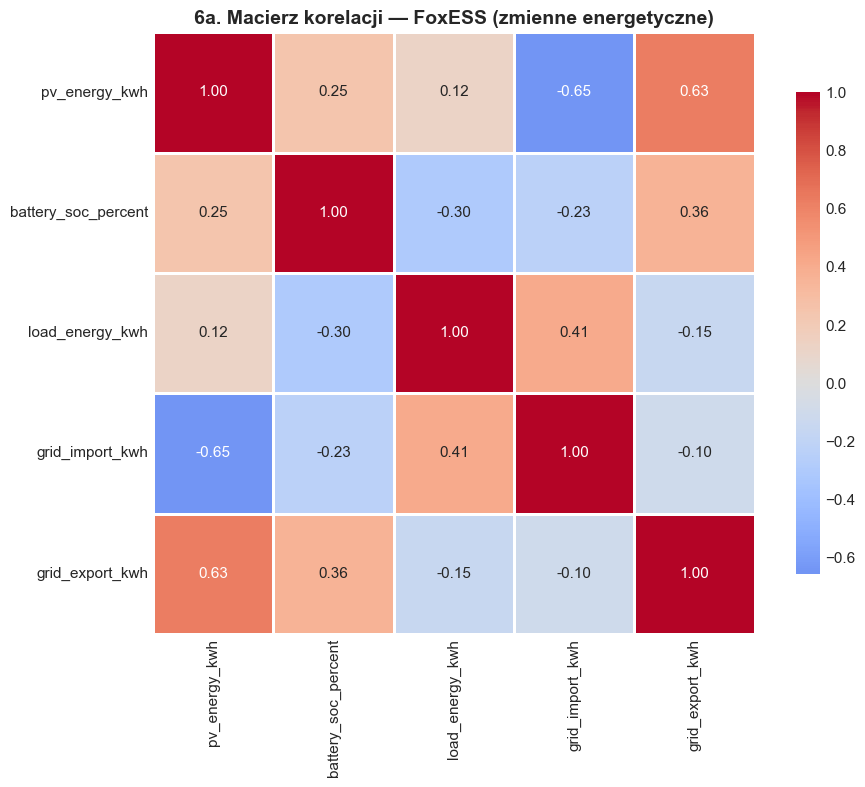

In [57]:
# 6a — Macierz korelacji FoxESS (zmienne energetyczne)
correlation_cols = [
    'pv_energy_kwh', 'battery_soc_percent', 'load_energy_kwh',
    'grid_import_kwh', 'grid_export_kwh',
]
corr_matrix = df_foxess[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=1, cbar_kws={'shrink': 0.8},
)
plt.title('6a. Macierz korelacji — FoxESS (zmienne energetyczne)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6b. Macierz korelacji — Open-Meteo vs produkcja PV (godzinowo)

Okno treningowe (daylight, archive): radiacja dodatnio, zachmurzenie ujemnie względem `pv_kwh_hour`.  
Warstwy `cloud_cover_low` / `mid` są w API — kandydat pod T2 (nie w 16 cechach produkcyjnych).


In [58]:
# 6b — Macierz korelacji pogodowej (Open-Meteo vs pv_kwh_hour)
from IPython.display import Image, display
from pathlib import Path

_docs = Path('..') / 'docs'
_wx_png = _docs / 'weather_correlation_matrix.png'
_wx_csv = Path('..') / 'data' / 'processed' / 'weather_correlation_vs_target.csv'

if _wx_png.exists():
    display(Image(filename=str(_wx_png), width=900))
else:
    print('⚠️ Brak', _wx_png, '— uruchom: python scripts/plot_weather_correlation.py')

if _wx_csv.exists():
    _rank = pd.read_csv(_wx_csv).sort_values('abs_corr', ascending=False)
    print('Top korelacje vs pv_kwh_hour:')
    display(_rank.head(8))
else:
    print('(opcjonalnie) brak CSV rankingu — ten sam skrypt zapisuje weather_correlation_vs_target.csv')


⚠️ Brak ../docs/weather_correlation_matrix.png — uruchom: python scripts/plot_weather_correlation.py
(opcjonalnie) brak CSV rankingu — ten sam skrypt zapisuje weather_correlation_vs_target.csv


## 7. Wnioski z analizy EDA

### Kluczowe obserwacje:
1. **Produkcja PV**: Silnie zależna od pory roku i pogody (radiacja +, zachmurzenie − — §6b)
2. **Zużycie energii**: Niestandardowy profil (pompa ciepła, ogrzewanie podłogowe)
3. **Autokonsumpcja**: Możliwe do poprawy przez inteligentne sterowanie baterią
4. **Taryfa G12w**: Duże różnice w cenach między strefami (dzień/noc)

### Data leakage — eliminacja importu Tauron z treningu
Dane Tauron (`tauron_bills`, `meter_readings`) służą **wyłącznie** do walidacji biznesowej. Model PV trenuje na FoxESS + Open-Meteo; nocne ładowanie z sieci nie wchodzi do targetu.

### Potencjał optymalizacji:
- Ładowanie baterii w strefie nocnej (tańsza energia)
- Maksymalizacja autoconsumption w dzień
- Unikanie importu energii w szczycie (droższa strefa)

### Następne kroki (lipiec 2026):
1. Monitorowanie MLOps — `sync_data.py` + `forecast_pv.py` (CRON)
2. Retrening RF godzinowego — `train_hourly_model_tuning.py`
3. Walidacja kalibracji śniegu/mgły — zdjęcia tylko jako sanity check
4. Szczegóły ML → [docs/02_ML_predykcja_PV.md](../docs/02_ML_predykcja_PV.md)


In [59]:
# Zamknięcie połączenia
conn.close()
print("✅ Analiza EDA zakończona")

✅ Analiza EDA zakończona
